In [50]:
# !nvidia-smi

In [51]:
# import torch
# print("Torch version:", torch.__version__)
# print("CUDA available:", torch.cuda.is_available())
# if torch.cuda.is_available():
#     print("GPU:", torch.cuda.get_device_name(0))
# else:
#     print("No GPU detected")

In [52]:
import zipfile

zip_path = "../einstein_rings/einstein_rings_128.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    image_files = [f for f in z.namelist() if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

print("Total images:", len(image_files))

Total images: 195


In [53]:
import os
from pathlib import Path

# ZIP_PATH =  "../einstein_rings/einstein_rings_128.zip"
DATA_DIR = "../einstein_rings/einstein_rings_all"
OUTPUT_DIR =  "../einstein_rings/diffusion_output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

DATA_DIR: ../einstein_rings/einstein_rings_all
OUTPUT_DIR: ../einstein_rings/diffusion_output


In [54]:
# %%capture
# !pip install -U diffusers[training]

In [55]:
# %%capture
# !sudo apt -qq install git-lfs
# !git config --global credential.helper store

In [56]:
from dataclasses import dataclass

@dataclass
class TrainingConfig:
    image_size = 64
    train_batch_size = 2
    eval_batch_size = 16
    num_epochs = 300
    gradient_accumulation_steps = 1
    learning_rate = 1e-4
    lr_warmup_steps = 100 
    save_image_epochs = 10
    save_model_epochs = 30
    mixed_precision = 'fp16'
    output_dir = 'ema-es-64-v6'
    push_to_hub = False # Set to False if you haven't fixed the 401 error yet
    overwrite_output_dir = True
    seed = 0

config = TrainingConfig()

In [57]:
from pathlib import Path
import os

valid_exts = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

best_folder = None
best_count = 0

for root, dirs, files in os.walk(DATA_DIR):
    count = sum(1 for f in files if Path(f).suffix.lower() in valid_exts)
    if count > best_count:
        best_count = count
        best_folder = root

print("Best image folder:", best_folder)
print("Number of images:", best_count)

Best image folder: ../einstein_rings/einstein_rings_all
Number of images: 195


Found images: 195


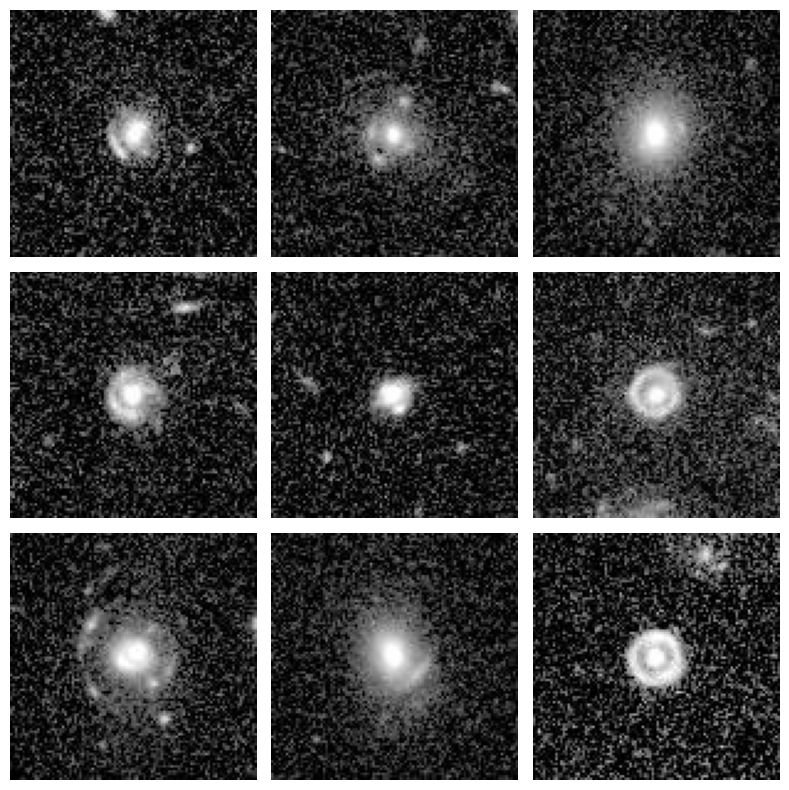

In [58]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import random

image_paths = []
for p in Path(DATA_DIR).glob("*"):
    if p.suffix.lower() in valid_exts:
        image_paths.append(str(p))

print("Found images:", len(image_paths))

sample_paths = random.sample(image_paths, min(9, len(image_paths)))

plt.figure(figsize=(8, 8))
for i, path in enumerate(sample_paths, 1):
    img = Image.open(path).convert("RGB")
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [59]:
from torchvision import transforms

# preprocess = transforms.Compose(
#     [
#         transforms.Resize((config.image_size, config.image_size)),
#         transforms.RandomHorizontalFlip(),
#         transforms.ToTensor(),
#         transforms.Normalize([0.5], [0.5]),
#     ]
# )
def log_transform(x):
    # This brings out the faint arcs without blowing out the center
    return torch.log1p(x * 100) / torch.log1p(torch.tensor(100.0))

preprocess = transforms.Compose([
    transforms.Resize((config.image_size, config.image_size)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(180),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]), 
])

In [60]:
import torch
train_dataloader = torch.utils.data.DataLoader(DATA_DIR, batch_size=config.train_batch_size, shuffle=True)

In [61]:
from diffusers import UNet2DModel
model = UNet2DModel(
    sample_size=config.image_size,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(64, 64, 128, 256, 512), # 5 stages
    down_block_types=(
        "DownBlock2D",      # 128 -> 64
        "DownBlock2D",      # 64 -> 32
        "DownBlock2D",      # 32 -> 16
        "AttnDownBlock2D",  # 16 -> 8
        "DownBlock2D",      # 8 -> 4
    ),
    up_block_types=(
        "UpBlock2D",        # 4 -> 8
        "AttnUpBlock2D",    # 8 -> 16
        "UpBlock2D",        # 16 -> 32
        "UpBlock2D",        # 32 -> 64
        "UpBlock2D",        # 64 -> 128
    ),
)
model.enable_gradient_checkpointing()

In [62]:
from PIL import Image
from pathlib import Path
from collections import Counter

sizes = []

for p in Path(DATA_DIR).glob("*"):
    if p.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp", ".webp"]:
        img = Image.open(p)
        sizes.append(img.size)

# Count occurrences of each size
size_count = Counter(sizes)

print("Image size distribution:")
for size, count in size_count.items():
    print(f"{size}: {count} images")

if sample_paths:
  example_image_path = sample_paths[0]
  example_image = Image.open(example_image_path).convert("RGB")
  preprocessed_image = preprocess(example_image)
  print('Input shape after preprocessing:', preprocessed_image.shape)

else:
  print("No sample paths found to determine image shape.")

Image size distribution:
(100, 100): 195 images
Input shape after preprocessing: torch.Size([1, 64, 64])


In [63]:
import torch
from PIL import Image
from torchvision import transforms
from pathlib import Path

# transform = transforms.Compose([
#     transforms.Resize((128,128)),
#     transforms.ToTensor(),            # [0,1]
#     transforms.Normalize([0.5]*3, [0.5]*3)  # [-1,1]
# ])

images = []

for p in Path(DATA_DIR).glob("*"):
    if p.suffix.lower() in valid_exts:
        img = Image.open(p).convert("RGB")
        img = preprocess(img)
        images.append(img)

images = torch.stack(images)  # shape: [N, 3, 64, 64]

print("Tensor shape:", images.shape)

Tensor shape: torch.Size([195, 1, 64, 64])


In [64]:
# from diffusers import DDPMScheduler

# noise_scheduler = DDPMScheduler(num_train_timesteps=200)

In [65]:
from diffusers import DDPMScheduler

# noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2")
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_schedule="squaredcos_cap_v2", # Change from "linear" to this
    clip_sample=True # This forces the model to stay within bounds
)

noise = torch.randn_like(images)

timesteps = torch.randint(0, 100, (images.shape[0],))

noisy_images = noise_scheduler.add_noise(images, noise, timesteps)

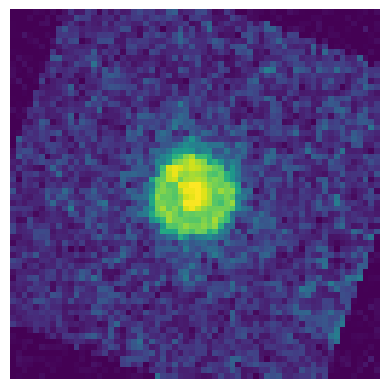

In [66]:
import matplotlib.pyplot as plt

img = noisy_images[190]

# convert back to [0,1]
img = (img.clamp(-1, 1) + 1) / 2
img = img.permute(1, 2, 0).cpu().numpy()



plt.imshow(img)
plt.axis("off")
plt.show()

Your original astronomy images are probably close to grayscale, but you converted them to RGB. Then Gaussian noise is added independently to each channel, so the result becomes colorful static. That is normal.


Show the same image at multiple timesteps:

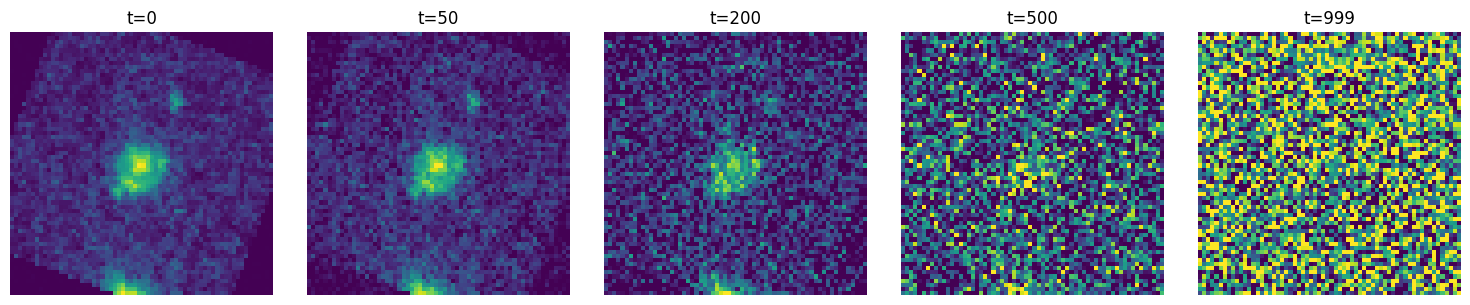

In [67]:
import matplotlib.pyplot as plt
import torch

img = images[3:4]  # one image, keep batch dim

steps = [0, 50, 200, 500, 999]

plt.figure(figsize=(15, 3))
for i, step in enumerate(steps, 1):
    noise = torch.randn_like(img)
    t = torch.tensor([step])
    noisy = noise_scheduler.add_noise(img, noise, t)

    show = (noisy[0].clamp(-1, 1) + 1) / 2
    show = show.permute(1, 2, 0).cpu().numpy()

    plt.subplot(1, len(steps), i)
    plt.imshow(show)
    plt.title(f"t={step}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [68]:
from torch.utils.data import DataLoader, TensorDataset

# 1. Ensure 'images' is a single big tensor (you already did this with torch.stack)
# images.shape should be [195, 3, 64, 64]

# 2. Wrap it in a Dataset so the DataLoader knows what to do with it
dataset = TensorDataset(images)

# 3. Create the DataLoader
train_dataloader = DataLoader(
    dataset,
    batch_size=config.train_batch_size,
    shuffle=True
)

In [ ]:
# from huggingface_hub import notebook_login

# notebook_login()

from huggingface_hub import login
login(token="HF_TOKEN")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [70]:
import torch.nn.functional as F
# 1. Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.enable_gradient_checkpointing()
# 2. Ensure model is on that device (do this once during setup)
model.to(device)

# 3. Move tensors to the device inside training loop
noisy_images = noisy_images.to(device)
timesteps = timesteps.to(device)
noise = noise.to(device) 

def tv_loss(img):
    # This measures the "jitter" between pixels
    w_variance = torch.sum(torch.abs(img[:, :, :, :-1] - img[:, :, :, 1:]))
    h_variance = torch.sum(torch.abs(img[:, :, :-1, :] - img[:, :, 1:, :]))
    return h_variance + w_variance

# Inside training loop:
noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
mse = F.mse_loss(noise_pred, noise)
# 0.00001 is a good starting point to clean the background without blurring the ring
loss = mse + 0.00001 * tv_loss(noise_pred)

C:\Users\teunm\AppData\Local\Temp\ipykernel_65492\3578620517.py:22: UserWarning: Using a target size (torch.Size([1, 1, 64, 64])) that is different to the input size (torch.Size([195, 1, 64, 64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  mse = F.mse_loss(noise_pred, noise)


In [71]:
# import torch.nn.functional as F

# noise_pred = model(noisy_images, timesteps).sample
# loss = F.mse_loss(noise_pred, noise)

In [72]:
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

In [73]:
from diffusers.optimization import get_cosine_schedule_with_warmup

lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=config.lr_warmup_steps,
    num_training_steps=(len(train_dataloader) * config.num_epochs),
)

In [74]:
# from diffusers import DDPMPipeline

# import math

# def make_grid(images, rows, cols):
#     w, h = images[0].size
#     grid = Image.new('RGB', size=(cols*w, rows*h))
#     for i, image in enumerate(images):
#         grid.paste(image, box=(i%cols*w, i//cols*h))
#     return grid

# def evaluate(config, epoch, pipeline):
#     # Sample some images from random noise (this is the backward diffusion process).
#     # The default pipeline output type is `List[PIL.Image]`
#     images = pipeline(
#         batch_size = config.eval_batch_size,
#         generator=torch.manual_seed(config.seed),
#     ).images

#     # Make a grid out of the images
#     image_grid = make_grid(images, rows=4, cols=4)

#     # Save the images
#     test_dir = os.path.join(config.output_dir, "samples")
#     os.makedirs(test_dir, exist_ok=True)
#     image_grid.save(f"{test_dir}/{epoch:04d}.png")

from diffusers import DDPMPipeline
import math
import os
import torch

def make_grid(images, rows, cols):
    w, h = images[0].size
    # Use 'L' for grayscale if your model is 1-channel, otherwise 'RGB'
    grid = Image.new('L', size=(cols*w, rows*h)) 
    for i, image in enumerate(images):
        grid.paste(image, box=(i%cols*w, i//cols*h))
    return grid

def evaluate(config, epoch, pipeline):
    # 1. REMOVE the fixed generator/seed so you get NEW images every time
    # 2. INCREASE num_inference_steps (e.g., 250) to remove the "colorful" grain
    images = pipeline(
        batch_size = config.eval_batch_size,
        num_inference_steps = 250, 
    ).images

    # 3. Dynamically calculate rows and columns based on your batch size
    # cols = 4
    # rows = math.ceil(len(images) / cols)
    # image_grid = make_grid(images, rows=rows, cols=cols)

    # Save the images
    test_dir = os.path.join(config.output_dir, "samples")
    os.makedirs(test_dir, exist_ok=True)
    # image_grid.save(f"{test_dir}/epoch_{epoch:04d}.png")
    for i, img in enumerate(images):
        img.save(f"{test_dir}/epoch_{epoch:04d}_sample_{i}.png")

In [75]:
from accelerate import Accelerator
from accelerate.utils import ProjectConfiguration
from huggingface_hub import create_repo, upload_folder
from diffusers.training_utils import EMAModel # Import EMA
from diffusers import DDPMPipeline
import torch.nn.functional as F
import torch
from tqdm.auto import tqdm
from pathlib import Path
import os

def train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler):
    # Initialize accelerator and tensorboard logging
    logging_dir = os.path.join(config.output_dir, "logs")
    accelerator_project_config = ProjectConfiguration(project_dir=config.output_dir, logging_dir=logging_dir)
    
    accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        log_with="tensorboard",
        project_config=accelerator_project_config,
    )

    if accelerator.is_main_process:
        if config.push_to_hub:
            repo_id = create_repo(repo_id=Path(config.output_dir).name, exist_ok=True).repo_id
        elif config.output_dir is not None:
            os.makedirs(config.output_dir, exist_ok=True)
        accelerator.init_trackers("train_example")

    # --- 1. Initialize EMA Model ---
    # We create a copy of the model parameters to maintain the moving average
    ema_model = EMAModel(model.parameters(), decay=0.999)

    # Prepare everything
    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    global_step = 0

    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, batch in enumerate(train_dataloader):
            # Standard data prep
            clean_images = batch[0]
            noise = torch.randn_like(clean_images)
            bs = clean_images.shape[0]
            timesteps = torch.randint(0, noise_scheduler.num_train_timesteps, (bs,), device=clean_images.device).long()

            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            with accelerator.accumulate(model):
                # Predict the noise residual
                noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
                loss = F.mse_loss(noise_pred, noise)
                accelerator.backward(loss)

                accelerator.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()
                
                # --- 2. Update EMA weights ---
                # This should happen after the optimizer step
                ema_model.step(model.parameters())

            progress_bar.update(1)
            logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0], "step": global_step}
            progress_bar.set_postfix(**logs)
            accelerator.log(logs, step=global_step)
            global_step += 1

        # --- 3. Evaluate and Save using EMA Weights ---
        if accelerator.is_main_process:
            # We want to evaluate the "smoothed" version of the model
            # First, temporarily copy EMA weights into the model
            ema_model.copy_to(model.parameters())
            
            pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)

            if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
                evaluate(config, epoch, pipeline)

            if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
                if config.push_to_hub:
                    upload_folder(
                        repo_id=repo_id,
                        folder_path=config.output_dir,
                        commit_message=f"Epoch {epoch} (EMA)",
                        ignore_patterns=["step_*", "epoch_*"],
                    )
                else:
                    pipeline.save_pretrained(config.output_dir)
            
            # NOTE: After saving/evaluating with EMA weights, your training continues 
            # using the weights that were already in 'model'. The copy_to() only 
            # affected the current epoch's evaluation/save.

In [77]:
from accelerate import notebook_launcher
args = (config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler)

notebook_launcher(train_loop, args, num_processes=1)

Launching training on one GPU.


Epoch 255: 100%|██████████| 98/98 [00:19<00:00,  5.10it/s, loss=0.00649, lr=5.27e-6, step=25087]


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

# Grab a sample from the model output
sample = noise_pred[0].detach().cpu()
# Reverse normalization correctly (ONLY ONCE)
sample = (sample / 2 + 0.5.).clamp(0, 1)

# If it's 3-channel, convert to grayscale to see the ring structure better
if sample.shape[0] == 3:
    sample = sample.mean(dim=0)

plt.figure(figsize=(6,6))
# 'magma' or 'inferno' are much better for seeing faint astronomical rings
plt.imshow(sample, cmap='magma')
plt.title("Model Prediction (Heatmap)")
plt.axis("off")
plt.show()

SyntaxError: invalid syntax (4131941598.py, line 6)

In [1]:
import glob

sample_images = sorted(glob.glob(f"{config.output_dir}/samples/*.png"))
Image.open(sample_images[-1])

NameError: name 'config' is not defined

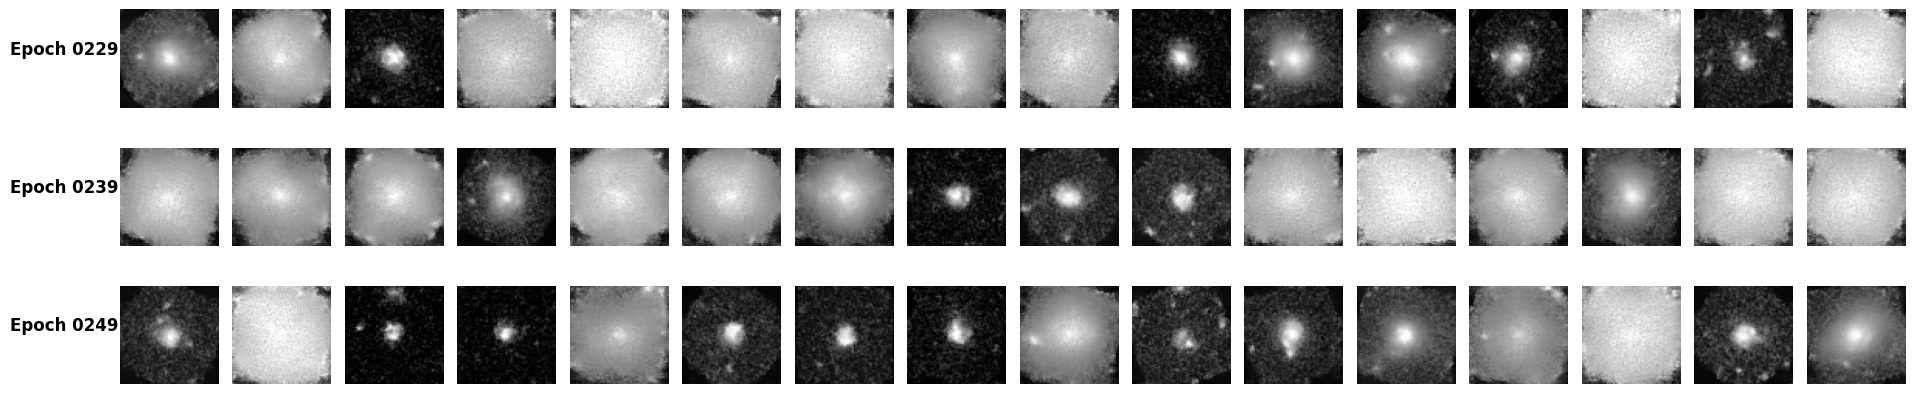

In [14]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import glob

# 1. Configuration
image_folder = './ema-es-64-v6/samples'
# Specify the epochs you want to see here:
target_epochs = ["0229", "0239", "0249"] 
images_per_row = 16 

# 2. Collect files for specific epochs
file_list = []
for epoch in target_epochs:
    # This finds all 16 samples for each specific epoch
    pattern = f"epoch_{epoch}_sample_*.png"
    files = sorted(glob.glob(os.path.join(image_folder, pattern)))
    file_list.extend(files)

if not file_list:
    print(f"No images found for epochs {target_epochs}! Check your path.")
else:
    # Calculate grid size based on target epochs
    num_rows = len(target_epochs)
    
    # 3. Create the plot
    # Adjusted figsize: 20 width for 16 images, height scaled by rows
    fig, axes = plt.subplots(num_rows, images_per_row, figsize=(20, 1.5 * num_rows))
    
    # Handle the case where there is only 1 row (axes wouldn't be a 2D array)
    if num_rows == 1:
        axes = axes.reshape(1, -1)

    for row_idx, epoch in enumerate(target_epochs):
        # Filter files for just this row's epoch
        row_files = [f for f in file_list if f"epoch_{epoch}" in f]
        
        for col_idx in range(images_per_row):
            ax = axes[row_idx, col_idx]
            if col_idx < len(row_files):
                img = Image.open(row_files[col_idx])
                ax.imshow(img, cmap='gray')
                
                # Label the start of each row with the Epoch number
                if col_idx == 0:
                    ax.set_ylabel(f"Epoch {epoch}", fontsize=12, fontweight='bold', rotation=0, labelpad=40)
            
            ax.set_xticks([])
            ax.set_yticks([])
            # Remove the frame/spines
            for spine in ax.spines.values():
                spine.set_visible(False)

    plt.tight_layout()
    plt.subplots_adjust(left=0.1) # Make room for the row labels
    plt.show()